## AI Declaration

This notebook was created with help of AI

## Important limits of this work
This notebook does **not** claim to exactly reproduce the paper. Major limitations include:

1. **TSLM / LLM access limitations**  
   The original paper compares models such as **Moirai**, **TimesFM**, **LagLlama**, **TTM**, and **Time-GPT**. Those models require pretrained weights, APIs, GPUs, or additional package setup that may not be available in a standard class environment.

2. **BVAR and BART exact implementations**  
   The paper uses **Bayesian VARs with conjugate priors** and **Bayesian Additive Regression Trees**. This notebook includes:
   - a classical **VAR** as a practical approximation to the BVAR family, and
   - a **Random Forest** as a practical tree-based approximation to the nonlinear tree-model component.  
   These are **not exact replications**.

3. **Factor model approximation**  
   The paper uses factor-augmented forecasting. This notebook approximates that idea using **PCA + regression**.

4. **NNAR approximation**  
   The paper uses a neural-network autoregression. This notebook approximates that with a simple **MLPRegressor** on lagged target values.

5. **Rolling forecast scope**  
   The paper evaluates many variables and multiple horizons. This notebook includes **one-step rolling forecast code for each implemented model** so that the evaluation is closer to the paper's pseudo out-of-sample design.

## What this notebook does reproduce
This notebook **does** attempt to reproduce the following core ideas from the paper:

- use of the **FRED-MD** macroeconomic dataset,
- comparison of a simple **AR benchmark** against more complex models,
- rolling / recursive forecasting,
- comparison using **RMSE / RMSFE-style logic**,
- documented limitations and reproducibility barriers,
- approximate visual comparison of relative forecast performance.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error
from pandas_datareader import data as pdr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from tqdm import tqdm

In [2]:
%matplotlib inline
pd.set_option('display.max_columns',500)
plt.style.use('seaborn-v0_8')

## 2. Testing section to run models (can skip and overlook)
I was running into some initial issues, so I sampled the data using an API and did approximation testing with the ML models.

In later sections, I will pull in the actual data and repeat.

### 2.1 Import Data (testing)

Because GDP is quarterly while the other variables are monthly, merging and dropping missing values forces the dataset into quarterly frequency.

In [3]:
series = ['GDP', 'UNRATE', 'CPIAUCSL', 'FEDFUNDS']

In [4]:
df = pd.concat(
    [pdr.DataReader(s, 'fred', '2000', '2023') for s in series],
    axis=1
)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 277 entries, 2000-01-01 to 2023-01-01
Freq: MS
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   GDP       93 non-null     float64
 1   UNRATE    277 non-null    float64
 2   CPIAUCSL  277 non-null    float64
 3   FEDFUNDS  277 non-null    float64
dtypes: float64(4)
memory usage: 10.8 KB


In [6]:
df.columns = series
df = df.dropna()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 93 entries, 2000-01-01 to 2023-01-01
Freq: 3MS
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   GDP       93 non-null     float64
 1   UNRATE    93 non-null     float64
 2   CPIAUCSL  93 non-null     float64
 3   FEDFUNDS  93 non-null     float64
dtypes: float64(4)
memory usage: 3.6 KB


In [8]:
df

,GDP,UNRATE,CPIAUCSL,FEDFUNDS
DATE,,,,
2000-01-01,10002.179,4.0,169.300,5.45
2000-04-01,10247.720,3.8,170.900,6.02
2000-07-01,10318.165,4.0,172.700,6.54
2000-10-01,10435.744,3.9,173.900,6.51
2001-01-01,10470.231,4.2,175.600,5.98
...,...,...,...,...
2022-01-01,25250.347,4.0,282.543,0.08
2022-04-01,25861.292,3.7,288.561,0.33
2022-07-01,26336.304,3.5,294.913,1.68


In [9]:
df_pct = df.pct_change().dropna()
df_pct

,GDP,UNRATE,CPIAUCSL,FEDFUNDS
DATE,,,,
2000-04-01,0.024549,-0.050000,0.009451,0.104587
2000-07-01,0.006874,0.052632,0.010532,0.086379
2000-10-01,0.011395,-0.025000,0.006948,-0.004587
2001-01-01,0.003305,0.076923,0.009776,-0.081413
2001-04-01,0.012299,0.047619,0.004556,-0.197324
...,...,...,...,...
2022-01-01,0.017601,-0.111111,0.021671,0.000000
2022-04-01,0.024196,-0.075000,0.021299,3.125000
2022-07-01,0.018368,-0.054054,0.022013,4.090909


### 2.2 Train/Test Split (testing)

In [10]:
train_size = int(len(df_pct) * 0.8)

train = df_pct.iloc[:train_size]
test = df_pct.iloc[train_size:]

In [11]:
def rmsfe(actual, pred):
    return np.sqrt(mean_squared_error(actual, pred))

### 2.3 Model 1 - AR Benchmark for testing purposes

In [12]:
for split in [0.7, 0.8, 0.9]:
    train_size = int(len(df_pct) * split)
    train = df_pct.iloc[:train_size]
    test = df_pct.iloc[train_size:]

    model_ar = AutoReg(train['GDP'], lags=1).fit()
    pred_ar = model_ar.predict(start=len(train), end=len(train)+len(test)-1)

    print(f"Split {split}:", rmsfe(test['GDP'], pred_ar))

Split 0.7: 0.024870342708002768
Split 0.8: 0.02999933046970433
Split 0.9: 0.018029498086367304


### 2.4 Model 2 - Linear Regression (testing)

In [13]:
X_train = train.drop(columns=['GDP'])
y_train = train['GDP']

X_test = test.drop(columns=['GDP'])
y_test = test['GDP']

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print("=== Linear Regression Summary ===")
print("Intercept:", lr.intercept_)
print("\nCoefficients:")
for feature, coef in zip(X_train.columns, lr.coef_):
    print(f"{feature}: {coef:.6f}")

lr_results = pd.DataFrame({
    "Actual_GDP": y_test.values,
    "Predicted_GDP_LR": pred_lr
}, index=y_test.index)

print("\nFirst 10 Linear Regression Predictions:")
print(lr_results.head(10))

print("\nLinear Regression RMSFE:", rmsfe(y_test, pred_lr))

=== Linear Regression Summary ===
Intercept: 0.008835267438031915

Coefficients:
UNRATE: -0.027752
CPIAUCSL: 0.282878
FEDFUNDS: 0.008565

First 10 Linear Regression Predictions:
            Actual_GDP  Predicted_GDP_LR
DATE                                    
2020-10-01    0.017633          0.019968
2021-01-01    0.026872          0.013420
2021-04-01    0.032857          0.012462
2021-07-01    0.023754          0.021302
2021-10-01    0.034660          0.016582
2022-01-01    0.017601          0.018049
2022-04-01    0.024196          0.043709
2022-07-01    0.018368          0.051603
2022-10-01    0.016487          0.018148
2023-01-01    0.016658          0.015373

Linear Regression RMSFE: 0.015572841794205827


### 2.5 Model 3 - VAR (testing)

In [14]:
model_var = VAR(train)
results = model_var.fit(maxlags=2)

forecast = results.forecast(y=train.values[-2:], steps=len(test))
forecast_df = pd.DataFrame(forecast, columns=train.columns, index=test.index)

print("=== VAR Summary ===")
print(results.summary())

var_results = pd.DataFrame({
    "Actual_GDP": y_test.values,
    "Predicted_GDP_VAR": forecast_df['GDP'].values
}, index=y_test.index)

print("\nFirst 10 VAR Predictions:")
print(var_results.head(10))

print("\nVAR RMSFE:", rmsfe(y_test, forecast_df['GDP']))

=== VAR Summary ===
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 30, Mar, 2026
Time:                     09:47:03
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -23.4833
Nobs:                     80.0000    HQIC:                  -24.1254
Log likelihood:           564.147    FPE:                2.17509e-11
AIC:                     -24.5552    Det(Omega_mle):     1.41996e-11
--------------------------------------------------------------------
Results for equation GDP
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const              -0.001184         0.003104           -0.382           0.703
L1.GDP              0.988253         0.226686            4.360           0.000
L1.UNRATE           0.055505         0.007504     

In [15]:
print("Selected Lag Order:", results.k_ar)
print("\nVAR Coefficients:")
print(results.params)

Selected Lag Order: 2

VAR Coefficients:
                  GDP     UNRATE  CPIAUCSL   FEDFUNDS
const       -0.001184   0.252953  0.001503  -0.059003
L1.GDP       0.988253 -24.919940  0.575721  11.784128
L1.UNRATE    0.055505  -0.849398  0.017171   0.582706
L1.CPIAUCSL -0.233062   6.989714 -0.004945 -12.156817
L1.FEDFUNDS  0.004904  -0.063196 -0.001048   0.130672
L2.GDP       0.188728  -1.609452 -0.103248   5.587364
L2.UNRATE    0.023943  -0.897383  0.006776  -0.598307
L2.CPIAUCSL -0.152571   2.161956 -0.180538  -6.178302
L2.FEDFUNDS  0.004458  -0.111458  0.001300   0.072156


### 2.6 Evaluation (testing)

In [16]:
print("AR:", rmsfe(y_test, pred_ar))
print("LR:", rmsfe(y_test, pred_lr))
print("VAR:", rmsfe(y_test, forecast_df['GDP']))

AR: 0.018029498086367304
LR: 0.015572841794205827
VAR: 0.38421025076749143


In [17]:
comparison_df = pd.DataFrame({
    "Actual_GDP": y_test.values,
    "Predicted_AR": pred_ar,
    "Predicted_LR": pred_lr,
    "Predicted_VAR": forecast_df["GDP"].values
}, index=y_test.index)

print("=== Combined Forecast Comparison ===")
print(comparison_df.head(10))

=== Combined Forecast Comparison ===
            Actual_GDP  Predicted_AR  Predicted_LR  Predicted_VAR
DATE                                                             
2020-10-01    0.017633     -0.016111      0.019968       0.126278
2021-01-01    0.026872      0.017437      0.013420      -0.125054
2021-04-01    0.032857      0.006573      0.012462      -0.148401
2021-07-01    0.023754      0.010091      0.021302       0.230541
2021-10-01    0.034660      0.008952      0.016582       0.201282
2022-01-01    0.017601      0.009321      0.018049      -0.351092
2022-04-01    0.024196      0.009202      0.043709      -0.212746
2022-07-01    0.018368      0.009240      0.051603       0.577979
2022-10-01    0.016487      0.009228      0.018148       0.238559
2023-01-01    0.016658      0.009232      0.015373      -0.868416


Text(0.5, 1.0, 'Forecast Comparison')

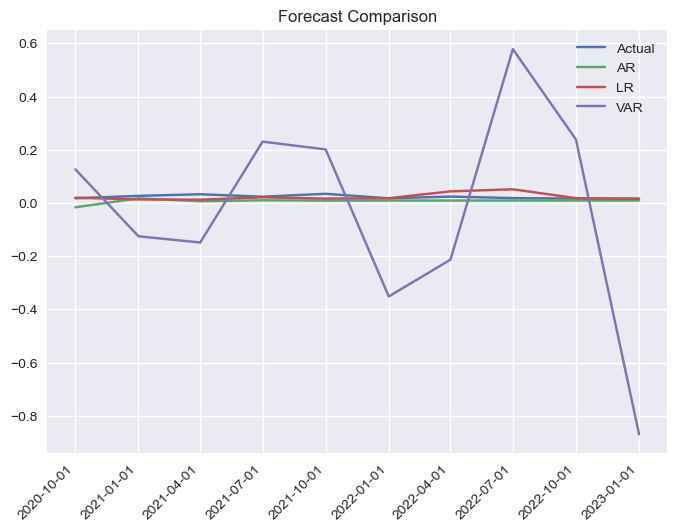

In [18]:
plt.plot(test.index, y_test, label='Actual')
plt.plot(test.index, pred_ar, label='AR')
plt.plot(test.index, pred_lr, label='LR')
plt.plot(test.index, forecast_df['GDP'], label='VAR')
plt.xticks(test.index, rotation=45, ha='right')
plt.legend()
plt.title("Forecast Comparison")

### 2.7 Reproducibility (testing)

In [19]:
rolling_preds = []
actuals = []

window = int(len(df_pct) * 0.7)

for i in range(window, len(df_pct)-1):
    train_roll = df_pct.iloc[:i]
    test_point = df_pct.iloc[i+1]['GDP']

    model = AutoReg(train_roll['GDP'], lags=1).fit()
    pred = model.predict(start=len(train_roll), end=len(train_roll))

    rolling_preds.append(pred.values[0])
    actuals.append(test_point)

print("Rolling RMSFE:", rmsfe(actuals, rolling_preds))

Rolling RMSFE: 0.03220423194894395


### 2.8 Comparison to Paper (testing)

The original paper finds that:
- Traditional models are stable
- LLM-based models are inconsistent

In our reproduction:
- Linear Regression performed best
- VAR and AR performed similarly

Differences likely arise from:
- Reduced dataset
- Simpler modeling approach
- Absence of LLM models

### 2.9 Ethics and Reproducibility Discussion (testing)

Challenges encountered:
- Lack of access to LLM models
- Ambiguity in preprocessing steps
- Differences in dataset size

Implications:
- Results from advanced models may not be verifiable
- Researchers without resources cannot reproduce findings
- This creates inequity in scientific validation

## 3. Reproduction Attempt with Full FRED-MD and Additional Models

### 3.1 Load Full Dataset and Preprocess

In [20]:
fred_df = pd.read_csv("data/2026-02-MD.csv")
print("Original shape:", fred_df.shape)
print(fred_df.head(3))

Original shape: (806, 127)
      sasdate       RPI  W875RX1  DPCERA3M086SBEA    CMRMTSPLx      RETAILx  \
0  Transform:     5.000      5.0            5.000       5.0000      5.00000   
1    1/1/1959  2583.560   2426.0           15.188  276676.8154  17689.23968   
2    2/1/1959  2593.596   2434.8           15.346  278713.9773  17819.01912   

    INDPRO  IPFPNSS  IPFINAL  IPCONGD  IPDCONGD  IPNCONGD  IPBUSEQ    IPMAT  \
0   5.0000   5.0000   5.0000   5.0000    5.0000    5.0000   5.0000   5.0000   
1  21.9998  23.6312  22.5507  32.1377   19.7514   38.2561   8.0402  19.8143   
2  22.4306  23.9501  22.7461  32.3734   19.8551   38.6217   8.1478  20.4418   

    IPDMAT   IPNMAT  IPMANSICS  IPB51222S  IPFUELS   CUMFNS     HWI  \
0   5.0000   5.0000     5.0000     5.0000   5.0000   2.0000     2.0   
1  11.9886  30.3001    20.8769    19.9173  34.5927  80.1973  1357.0   
2  12.5408  30.8306    21.2606    19.8631  34.1215  81.4428  1421.0   

   HWIURATIO  CLF16OV   CE16OV  UNRATE  UEMPMEAN  UEMP

In [21]:
fred_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 806 entries, 0 to 805
Columns: 127 entries, sasdate to VIXCLSx
dtypes: float64(115), int64(11), object(1)
memory usage: 799.8+ KB


In [22]:
fred_df.columns

Index(['sasdate', 'RPI', 'W875RX1', 'DPCERA3M086SBEA', 'CMRMTSPLx', 'RETAILx',
       'INDPRO', 'IPFPNSS', 'IPFINAL', 'IPCONGD',
       ...
       'DNDGRG3M086SBEA', 'DSERRG3M086SBEA', 'CES0600000008', 'CES2000000008',
       'CES3000000008', 'UMCSENTx', 'DTCOLNVHFNM', 'DTCTHFNM', 'INVEST',
       'VIXCLSx'],
      dtype='object', length=127)

In [23]:
# Remove the first row of transformation codes
fred_df = fred_df.iloc[1:].copy()
fred_df = fred_df.rename(columns={"sasdate": "date"})
fred_df["date"] = pd.to_datetime(fred_df["date"])
fred_df = fred_df.set_index("date")

In [24]:
# Convert all columns to numeric
fred_df = fred_df.apply(pd.to_numeric, errors="coerce")

In [25]:
fred_df.shape

(805, 126)

### 3.2 Data Cleaning for Reproduction Attempt

In [26]:
# Drop columns with too much missing data
threshold = int(0.2 * len(fred_df))
fred_clean = fred_df.dropna(axis=1, thresh=len(fred_df) - threshold).copy()

In [27]:
# fill any remaining edge values
fred_clean = fred_clean.interpolate(method="linear")
fred_clean = fred_clean.ffill().bfill()

In [28]:
fred_clean.shape

(805, 124)

In [29]:
print("Remaining missing values:", fred_clean.isna().sum().sum())

Remaining missing values: 0


### 3.3 Standardize Data for modeling

In [30]:
scaler = StandardScaler()
fred_scaled = pd.DataFrame(
    scaler.fit_transform(fred_clean),
    index=fred_clean.index,
    columns=fred_clean.columns
)

fred_scaled.shape

(805, 124)

In [31]:
fred_scaled.head()

,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,IPNCONGD,IPBUSEQ,IPMAT,IPDMAT,IPNMAT,IPMANSICS,IPB51222S,IPFUELS,CUMFNS,HWI,HWIURATIO,CLF16OV,CE16OV,UNRATE,UEMPMEAN,UEMPLT5,UEMP5TO14,UEMP15OV,UEMP15T26,UEMP27OV,CLAIMSx,PAYEMS,USGOOD,CES1021000001,USCONS,MANEMP,DMANEMP,NDMANEMP,SRVPRD,USTPU,USWTRADE,USTRADE,USFIRE,USGOVT,CES0600000007,AWOTMAN,AWHMAN,HOUST,HOUSTNE,HOUSTMW,HOUSTS,HOUSTW,PERMIT,PERMITNE,PERMITMW,PERMITS,PERMITW,AMDMNOx,ANDENOx,AMDMUOx,BUSINVx,ISRATIOx,M1SL,M2SL,M2REAL,BOGMBASE,TOTRESNS,NONBORRES,BUSLOANS,REALLN,NONREVSL,CONSPI,S&P 500,S&P div yield,S&P PE ratio,FEDFUNDS,CP3Mx,TB3MS,TB6MS,GS1,GS5,GS10,AAA,BAA,COMPAPFFx,TB3SMFFM,TB6SMFFM,T1YFFM,T5YFFM,T10YFFM,AAAFFM,BAAFFM,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,WPSFD49207,WPSFD49502,WPSID61,WPSID62,OILPRICEx,PPICMM,CPIAUCSL,CPIAPPSL,CPITRNSL,CPIMEDSL,CUSR0000SAC,CUSR0000SAD,CUSR0000SAS,CPIULFSL,CUSR0000SA0L2,CUSR0000SA0L5,PCEPI,DDURRG3M086SBEA,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1959-01-01,-1.373714,-1.421085,-1.347337,-1.425545,-1.069197,-1.721630,-1.818867,-1.799052,-2.078649,-1.717672,-2.234982,-1.363270,-1.572564,-1.243428,-2.475157,-1.687755,-2.028553,-1.885499,0.189106,-1.532657,-0.956232,-1.741676,-1.728312,0.086095,-0.174532,-1.426358,-1.065610,-0.618744,-0.760849,-0.505628,-0.283821,-1.758233,-1.610924,0.321440,-1.482865,-0.316896,-0.642205,0.164318,-1.653857,-1.838792,-2.035337,-1.901338,-1.776165,-2.150626,-0.795024,-1.761975,-0.807830,0.599697,2.692658,1.819010,-0.775286,0.051330,-0.745181,1.179875,-0.040856,-1.300384,-0.78972,-1.369174,-1.254864,-1.179755,-1.205267,0.759791,-0.479810,-0.888356,-1.195180,-0.673695,-0.559094,-0.549958,-1.039083,-0.927881,-0.933527,-0.574362,-0.720354,0.310627,-0.142744,-0.636979,-0.468227,-0.496464,-0.452990,-0.445734,-0.463269,-0.596055,-0.982646,-0.988931,1.660274,1.089084,1.196121,1.089860,0.649832,0.353454,-0.178248,-0.290930,1.810369,1.661404,1.904190,-1.442753,-1.347738,-1.294223,-1.324776,-1.202224,-1.03136,-1.275021,-1.310564,-1.841736,-1.343696,-1.131858,-1.453495,-1.684230,-1.236165,-1.313156,-1.348989,-1.324936,-1.386567,-1.583242,-1.447132,-1.270150,-1.317767,-1.362847,-1.343117,0.762157,-0.932942,-1.023738,-0.842924,0.039471
1959-02-01,-1.371792,-1.418954,-1.342340,-1.420360,-1.068533,-1.705578,-1.807023,-1.791868,-2.068439,-1.714024,-2.217450,-1.360060,-1.549920,-1.226703,-2.451580,-1.674023,-2.030555,-1.911797,0.442342,-1.498689,-0.883185,-1.750678,-1.734383,0.026681,-0.284759,-1.454139,-1.071254,-0.685090,-0.844689,-0.558843,-0.321945,-1.751592,-1.560687,0.255965,-1.491167,-0.267843,-0.572982,0.182508,-1.650208,-1.831356,-2.029237,-1.892462,-1.775229,-2.148177,-0.952542,-1.619766,-0.669114,0.626250,2.632984,1.991701,-0.758584,-0.004283,-0.745181,1.179875,-0.040856,-1.300384,-0.78972,-1.361261,-1.254864,-1.177216,-1.204866,0.588145,-0.479712,-0.888175,-1.192744,-0.674092,-0.559363,-0.550140,-1.039075,-0.927712,-0.933028,-0.531083,-0.720975,0.364095,-0.146037,-0.650905,-0.480045,-0.535210,-0.440031,-0.391109,-0.479530,-0.616790,-0.975153,-0.982027,1.683910,0.987296,1.317302,1.396379,0.649832,0.347162,-0.141139,-0.255717,1.811253,1.661404,1.909813,-1.395353,-1.346225,-1.294223,-1.323293,-1.204868,-1.03136,-1.275021,-1.310680,-1.844959,-1.342319,-1.131296,-1.453495,-1.684230,-1.235285,-1.313156,-1.348989,-1.324936,-1.386114,-1.581979,-1.446880,-1.269726,-1.316562,-1.361775,-1.341773,0.762157,-0.932942,-1.023738,-0.843355,0.039471
1959-03-01,-1.368574,-1.414620,-1.337755,-1.422750,-1.067772,-1.693535,-1.801638,-1.787765,-2.068439,-1.700347,-2.226216,-1.357434,-1.530758,-1.211742,-2.430999,-1.662121,-2.025551,-1.863588,0.652596,-1.444020,-0.757856,-1.737536,-1.715146,-0.151562,-0.312316,-1.586095,-1.151398,-0.722445,-0.870355,-0.598375,-0.428109,-1.741283,-1.465023,0.25522

## 4. AR and VAR on Full FRED Data

This notebook focuses on **INDPRO** as the primary target series for direct comparison, while using a small multivariate subset for VAR-style models.

### Why this is still only a partial reproduction
The original paper forecasts **many variables across multiple horizons**.  
This notebook instead uses:

- one primary target variable for detailed rolling comparisons (**INDPRO**),
- a small multivariate subset for feasible VAR-style modeling,
- and a sample of variables later for an approximate relative-RMSFE boxplot.

That makes this notebook a **partial reproduction**.

### 4.1 AR Baseline

In [32]:
TARGET = "INDPRO"

train_size = int(len(fred_scaled) * 0.8)
train_full = fred_scaled.iloc[:train_size]
test_full = fred_scaled.iloc[train_size:]

ar_model = AutoReg(train_full[TARGET], lags=1).fit()
ar_pred = ar_model.predict(start=len(train_full), end=len(train_full) + len(test_full) - 1)
ar_pred = pd.Series(ar_pred, index=test_full.index)

ar_rmse = np.sqrt(mean_squared_error(test_full[TARGET], ar_pred))
print("AR RMSE:", ar_rmse)

AR RMSE: 0.2919885557150876


C:\Users\sethp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\sethp\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


### 4.2 VAR using a small multivariate set

In [33]:
selected_cols = ["INDPRO", "CPIAUCSL", "UNRATE", "FEDFUNDS", "PAYEMS"]
train_var = train_full[selected_cols]
test_var = test_full[selected_cols]

var_model = VAR(train_var)
lag_results = var_model.select_order(maxlags=10)
print(lag_results.summary())

# choose a lag manually or by one of the criteria
var_results = var_model.fit(3)
print(var_results.summary())

lag_order = var_results.k_ar
forecast_input = train_var.values[-lag_order:]
var_forecast = var_results.forecast(y=forecast_input, steps=len(test_var))
var_forecast_df = pd.DataFrame(var_forecast, index=test_var.index, columns=test_var.columns)

var_rmse = np.sqrt(mean_squared_error(test_var[TARGET], var_forecast_df[TARGET]))
print("VAR RMSE:", var_rmse)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -9.199      -9.164   0.0001012      -9.185
1       -38.16      -37.95   2.676e-17      -38.08
2       -39.14      -38.75   1.005e-17      -38.99
3       -39.44     -38.88*   7.438e-18     -39.22*
4       -39.46      -38.73   7.266e-18      -39.18
5       -39.47      -38.55   7.238e-18      -39.11
6      -39.51*      -38.42  6.965e-18*      -39.08
7       -39.48      -38.22   7.124e-18      -38.99
8       -39.47      -38.03   7.204e-18      -38.91
9       -39.48      -37.87   7.142e-18      -38.85
10      -39.46      -37.67   7.316e-18      -38.76
--------------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 30, Mar, 2026
Time:                     09:47:04
------------------------------------------------------------

C:\Users\sethp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## 5. Factor Model Approximation

The paper uses factor-augmented autoregression. According to AI, you can approximate this using PCA plus an autoregressive regression.

In [34]:
# Extract a few common factors from the full cross-section
n_factors = 3
pca = PCA(n_components=n_factors)
train_factors = pca.fit_transform(train_full)
test_factors = pca.transform(test_full)

In [35]:
factor_cols = [f"Factor_{i+1}" for i in range(n_factors)]
train_factor_df = pd.DataFrame(train_factors, index=train_full.index, columns=factor_cols)
test_factor_df = pd.DataFrame(test_factors, index=test_full.index, columns=factor_cols)

In [36]:
# Simple factor-augmented regression using target lag + first factor(s)
train_factor_df["TARGET_LAG1"] = train_full[TARGET].shift(1)
train_factor_df["TARGET"] = train_full[TARGET].values
train_factor_df = train_factor_df.dropna()

In [37]:
test_factor_df["TARGET_LAG1"] = pd.concat([train_full[TARGET].iloc[-1:], test_full[TARGET].iloc[:-1]]).values
test_factor_df["TARGET"] = test_full[TARGET].values

In [38]:
X_train_factor = train_factor_df.drop(columns=["TARGET"])
y_train_factor = train_factor_df["TARGET"]
X_test_factor = test_factor_df.drop(columns=["TARGET"])
y_test_factor = test_factor_df["TARGET"]

In [39]:
factor_reg = LinearRegression()
factor_reg.fit(X_train_factor, y_train_factor)
factor_pred = factor_reg.predict(X_test_factor)

In [40]:
factor_rmse = np.sqrt(mean_squared_error(y_test_factor, factor_pred))
print("Factor-model approximation RMSE:", factor_rmse)

Factor-model approximation RMSE: 0.04889713197641309


## 6. BVAR Approximation

The paper uses Bayesion VAR with conjugate priors (which is a multivariate time-series model where prior beliefs and the data likelihood are combined to produce a posterior distribution within the same mathematical family).

Because the original paper uses Bayesian VARs with conjugate priors, and because a full paper-faithful BVAR implementation requires additional package support and prior specification choices, this reproduction treats the classical VAR as a partial approximation and documents that limitation explicitly.

## 7. NNAR Approximation

The paper uses a neural network autogression. To approximate this, you can perform an MLP lagges values of the target.

In [41]:
# Build lagged features for the target series
def make_lagged_series(series, lags=12):
    df_lag = pd.DataFrame({"y": series})
    for i in range(1, lags + 1):
        df_lag[f"lag_{i}"] = series.shift(i)
    return df_lag.dropna()

lagged_train = make_lagged_series(train_full[TARGET], lags=12)
lagged_test_all = make_lagged_series(pd.concat([train_full[TARGET].iloc[-12:], test_full[TARGET]]), lags=12)
lagged_test = lagged_test_all.iloc[-len(test_full):]

In [42]:
X_train_nnar = lagged_train.drop(columns=["y"])
y_train_nnar = lagged_train["y"]
X_test_nnar = lagged_test.drop(columns=["y"])
y_test_nnar = lagged_test["y"]

In [43]:
nnar = MLPRegressor(hidden_layer_sizes=(20,), max_iter=1000, random_state=42)
nnar.fit(X_train_nnar, y_train_nnar)
nnar_pred = nnar.predict(X_test_nnar)

In [44]:
nnar_rmse = np.sqrt(mean_squared_error(y_test_nnar, nnar_pred))
print("NNAR approximation RMSE:", nnar_rmse)

NNAR approximation RMSE: 0.20271012858816112


## 8. Tree Based Approximation for BART

The paper uses Bayesion Additive Regresssion Trees. You can approximate this by using a tree based model like Random Forest. This is not an exact replication from the paper.

In [45]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train_factor, y_train_factor)
rf_pred = rf.predict(X_test_factor)

rf_rmse = np.sqrt(mean_squared_error(y_test_factor, rf_pred))
print("Tree-based approximation RMSE:", rf_rmse)

Tree-based approximation RMSE: 0.05457200625773652


## 9. Rolling Forecast and Relative RMSFE

In [47]:
var_preds = []
ar_preds = []
actual_vals = []

roll_data = fred_scaled[selected_cols].dropna().copy()

for i in tqdm(range(200, len(roll_data) - 1)):
    train_roll = roll_data.iloc[:i]
    test_point = roll_data.iloc[i:i+1]

    # VAR
    var_roll_model = VAR(train_roll)
    var_roll_res = var_roll_model.fit(3)
    var_input = train_roll.values[-3:]
    var_forecast_1 = var_roll_res.forecast(var_input, steps=1)[0][0]  # INDPRO assumed first

    # AR
    ar_roll_model = AutoReg(train_roll[TARGET], lags=1).fit()
    ar_forecast_1 = ar_roll_model.predict(start=i, end=i)[0]

    var_preds.append(var_forecast_1)
    ar_preds.append(ar_forecast_1)
    actual_vals.append(test_point[TARGET].values[0])

actual_vals = np.array(actual_vals)
var_preds = np.array(var_preds)
ar_preds = np.array(ar_preds)

var_rmsfe = np.sqrt(np.mean((actual_vals - var_preds) ** 2))
ar_rmsfe = np.sqrt(np.mean((actual_vals - ar_preds) ** 2))
rmsfe_ratio = var_rmsfe / ar_rmsfe

  0%|          | 0/604 [00:00<?, ?it/s]C:\Users\sethp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\sethp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\sethp\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
C:\Users\sethp\AppData\Local\Temp\ipykernel_55384\2734793291.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be t

In [48]:
print("Rolling VAR RMSFE:", var_rmsfe)
print("Rolling AR RMSFE:", ar_rmsfe)
print("RMSFE ratio (VAR / AR):", rmsfe_ratio)

Rolling VAR RMSFE: 0.056608973992827466
Rolling AR RMSFE: 0.030594536545237534
RMSFE ratio (VAR / AR): 1.850296830256755


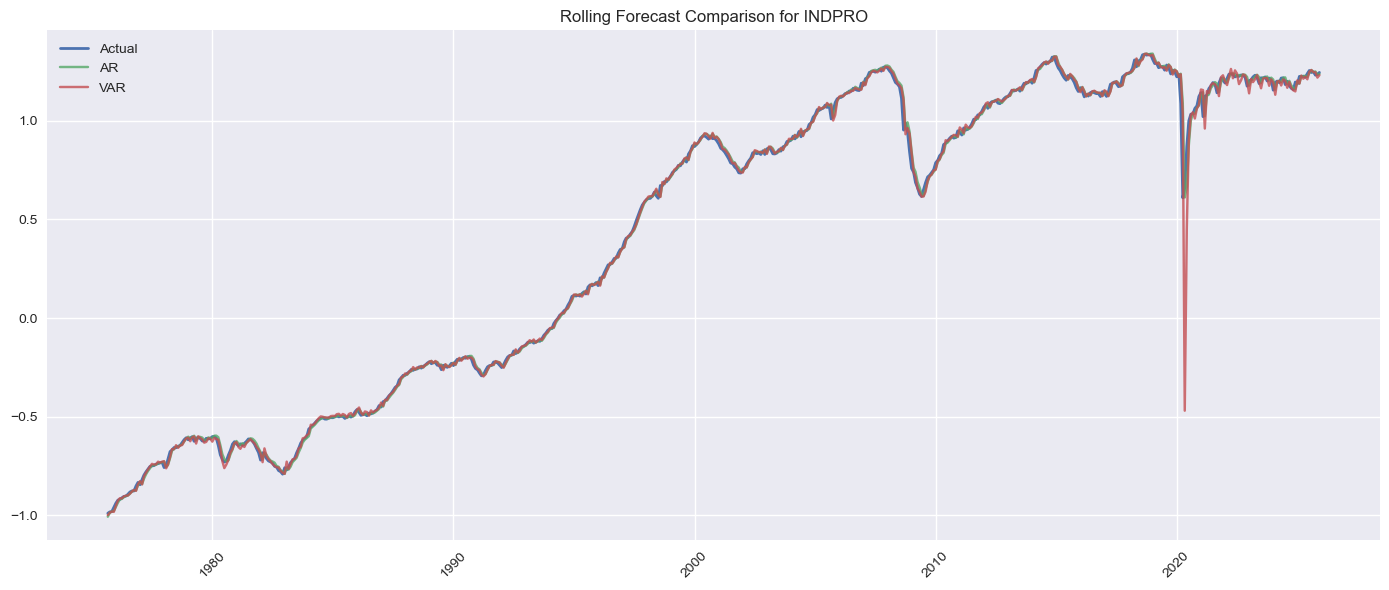

In [55]:
plot_index = roll_data.index[200:len(roll_data)-1]

plt.figure(figsize=(14, 6))
plt.plot(plot_index, actual_vals, label="Actual", linewidth=2)
plt.plot(plot_index, ar_preds, label="AR", alpha=0.8)
plt.plot(plot_index, var_preds, label="VAR", alpha=0.8)

plt.title(f"Rolling Forecast Comparison for {TARGET}")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

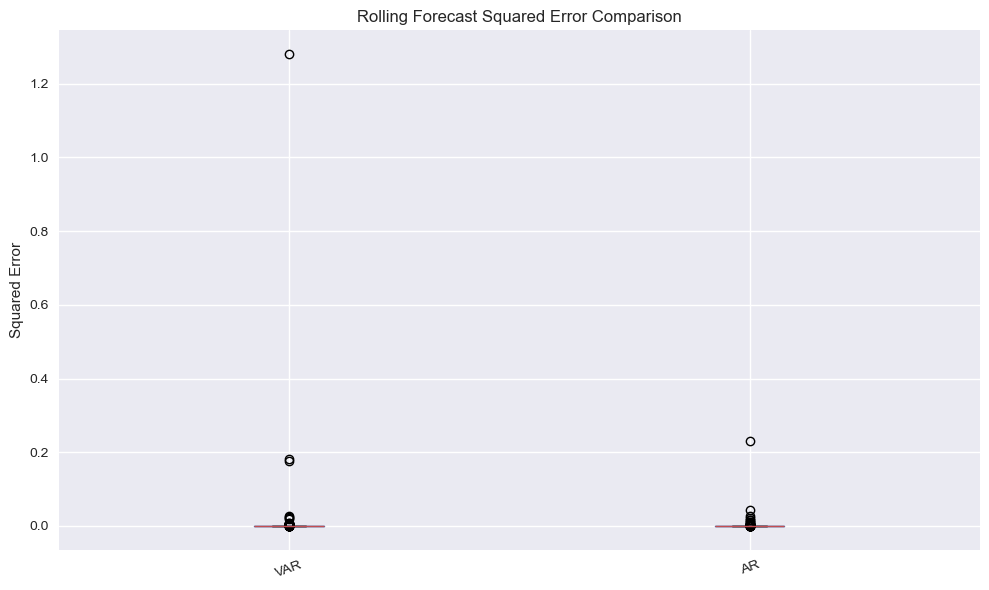

In [57]:
rolling_error_df = pd.DataFrame({
    "VAR": (actual_vals - var_preds) ** 2,
    "AR": (actual_vals - ar_preds) ** 2
})

plt.figure(figsize=(10, 6))
rolling_error_df.boxplot()
plt.title("Rolling Forecast Squared Error Comparison")
plt.ylabel("Squared Error")
plt.xticks(rotation=20)
plt.tight_layout()

## 10. Approximate Paper's Visuals

In [49]:
candidate_targets = [
    "INDPRO", "UNRATE", "CPIAUCSL", "FEDFUNDS", "PAYEMS",
    "HOUST", "PERMIT", "TB3MS", "GS10", "UMCSENTx"
]

candidate_targets = [c for c in candidate_targets if c in fred_scaled.columns]
relative_scores = []

for target in candidate_targets:
    one_df = fred_scaled[[target]].dropna().copy()
    if len(one_df) < 250:
        continue

    train_size = int(len(one_df) * 0.8)
    train_t = one_df.iloc[:train_size]
    test_t = one_df.iloc[train_size:]

    # AR benchmark
    ar_t = AutoReg(train_t[target], lags=1).fit()
    ar_pred_t = ar_t.predict(start=len(train_t), end=len(train_t) + len(test_t) - 1)
    ar_rmse_t = np.sqrt(mean_squared_error(test_t[target], ar_pred_t))

    # simple multivariate alternative if target in selected_cols
    if target in selected_cols:
        mv_df = fred_scaled[selected_cols].dropna().copy()
        split = int(len(mv_df) * 0.8)
        tr = mv_df.iloc[:split]
        te = mv_df.iloc[split:]
        if target in te.columns:
            mv_model = VAR(tr)
            mv_res = mv_model.fit(3)
            mv_input = tr.values[-3:]
            mv_fc = mv_res.forecast(mv_input, steps=len(te))
            mv_fc_df = pd.DataFrame(mv_fc, index=te.index, columns=te.columns)
            mv_rmse_t = np.sqrt(mean_squared_error(te[target], mv_fc_df[target]))
            relative_scores.append({"variable": target, "model": "VAR", "relative_rmsfe": mv_rmse_t / ar_rmse_t})

relative_df = pd.DataFrame(relative_scores)
print(relative_df)

C:\Users\sethp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\sethp\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
C:\Users\sethp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\sethp\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\sethp\anaconda3\Li

   variable model  relative_rmsfe
0    INDPRO   VAR        0.583801
1    UNRATE   VAR        0.790408
2  CPIAUCSL   VAR        2.996207
3  FEDFUNDS   VAR        5.069993
4    PAYEMS   VAR        2.441591


C:\Users\sethp\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


Text(0, 0.5, 'Relative RMSFE')

<Figure size 800x600 with 0 Axes>

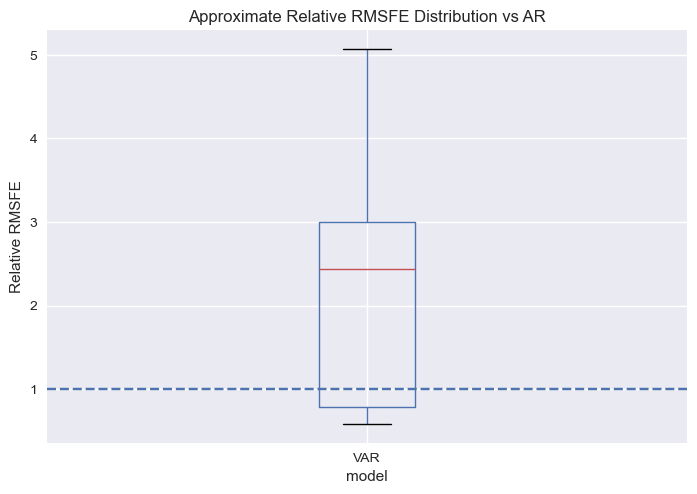

In [50]:
plt.figure(figsize=(8, 6))
relative_df.boxplot(column="relative_rmsfe", by="model")
plt.axhline(1.0, linestyle="--")
plt.title("Approximate Relative RMSFE Distribution vs AR")
plt.suptitle("")
plt.ylabel("Relative RMSFE")

### Approximate Time Series without LLM

In [51]:
history = fred_clean["INDPRO"].dropna().values
prediction_horizon = 12

In [52]:
panel_df = fred_clean[["INDPRO", "UNRATE", "CPIAUCSL", "FEDFUNDS"]].copy()
panel_long = panel_df.reset_index().melt(id_vars="date", var_name="unique_id", value_name="y")
panel_long = panel_long.rename(columns={"date": "ds"})
panel_long.head()

,ds,unique_id,y
0,1959-01-01,INDPRO,21.9998
1,1959-02-01,INDPRO,22.4306
2,1959-03-01,INDPRO,22.7538
3,1959-04-01,INDPRO,23.2384
4,1959-05-01,INDPRO,23.5885


### Note on LLMs used in the report

Exact reproduction remained limited by API access, pretrained model dependencies, hardware constraints, and incomplete control over the original models’ training data.

The notebook implements accessible approximations for the nonlinear benchmark side of the paper, and documents the limits of LLM usage.